In [61]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [62]:
df = pd.read_parquet("/Users/YGT/ist-airport-decision-support-system/data/silver/trajectories/trajectory_all.parquet")

In [63]:
df.head()

,hex,icao,date,trajectory_timestamp,point_timestamp,latitude,longitude,altitude_baro,ground_speed,track,baro_rate,nav_altitude_mcp,distance_km,on_ground
0,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:30:57+00:00,40.965736,28.553780,3075.0,232.0,101.900002,NaN,3250.0,38.212997,False
1,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:31:01+00:00,40.964951,28.559143,3075.0,229.5,101.300003,-64.0,3250.0,38.099117,False
2,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:33:50+00:00,41.033752,28.711670,3075.0,200.0,359.399994,NaN,3250.0,27.067278,False
3,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:03+00:00,41.045746,28.711731,3075.0,188.0,0.600000,NaN,3250.0,25.743839,False
4,4bb061,4bb061,2025-08-01,2025-08-01 00:00:00+00:00,2025-08-01 07:34:07+00:00,41.049156,28.711706,3075.0,182.0,359.700012,NaN,3250.0,25.368038,False


In [64]:
df = df[["icao", "date", "trajectory_timestamp", "point_timestamp",	"latitude",	"longitude", "altitude_baro" ,"distance_km", "on_ground"]]

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31844737 entries, 0 to 31844736
Data columns (total 9 columns):
 #   Column                Dtype              
---  ------                -----              
 0   icao                  str                
 1   date                  str                
 2   trajectory_timestamp  datetime64[ms, UTC]
 3   point_timestamp       datetime64[ms, UTC]
 4   latitude              float32            
 5   longitude             float32            
 6   altitude_baro         float32            
 7   distance_km           float32            
 8   on_ground             bool               
dtypes: bool(1), datetime64[ms, UTC](2), float32(4), str(2)
memory usage: 1.9 GB


In [66]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           4332
distance_km                0
on_ground                  0
dtype: int64

## Duplicate Data Control

In [67]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df = df.drop_duplicates(subset=["icao", "point_timestamp"], keep="last")

In [68]:
df.duplicated().sum()

np.int64(0)

## Missing Value Control

In [69]:
df.isna().sum()

icao                       0
date                       0
trajectory_timestamp       0
point_timestamp            0
latitude                   0
longitude                  0
altitude_baro           3562
distance_km                0
on_ground                  0
dtype: int64

In [70]:
missing = df["altitude_baro"].isna().sum()
ratio = missing / len(df)

print("Missing:", missing)
print("Ratio:", ratio)

Missing: 3562
Ratio: 0.00011623549454776561


## Removing Extreme Values

In [71]:
df["altitude_baro"].describe([0, 0.25, 0.50, 0.75, 0.80, 0.90])

count    3.064112e+07
mean     1.652721e+04
std      1.252107e+04
min     -9.000000e+02
0%      -9.000000e+02
25%      5.375000e+03
50%      1.232500e+04
75%      2.747500e+04
80%      3.300000e+04
90%      3.600000e+04
max      8.170000e+04
Name: altitude_baro, dtype: float64

In [72]:
len(df)

30644684

In [73]:
df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
].shape

(30641039, 9)

In [74]:
df = df[
    (df['altitude_baro'] > -1000) &
    (df['altitude_baro'] < 50000)
]

## Flight Segmentation

In [75]:
df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

In [76]:
df["dt_s"] = df.groupby("icao")["point_timestamp"].diff().dt.total_seconds()

In [77]:
(df["dt_s"] < 0).sum()

np.int64(0)

In [78]:
df["dt_s"].describe([0, 0.10,0.25, 0.50, 0.75, 0.80, 0.90])

count    3.063062e+07
mean     5.027075e+03
std      1.473475e+05
min      1.000000e+00
0%       1.000000e+00
10%      1.000000e+00
25%      3.000000e+00
50%      6.000000e+00
75%      1.300000e+01
80%      1.600000e+01
90%      2.000000e+01
max      2.772001e+07
Name: dt_s, dtype: float64

In [79]:
df["dt_s"].describe(percentiles=[.9,.95,.99,.999])

count    3.063062e+07
mean     5.027075e+03
std      1.473475e+05
min      1.000000e+00
90%      2.000000e+01
95%      3.700000e+01
99%      3.132300e+04
99.9%    1.088273e+06
max      2.772001e+07
Name: dt_s, dtype: float64

   MAX_GAP_S  n_episodes
0         60     1226318
1        120      998708
2        180      919936
3        300      828797
4        600      756546
5        900      733337
6       1200      720410
7       1800      715532


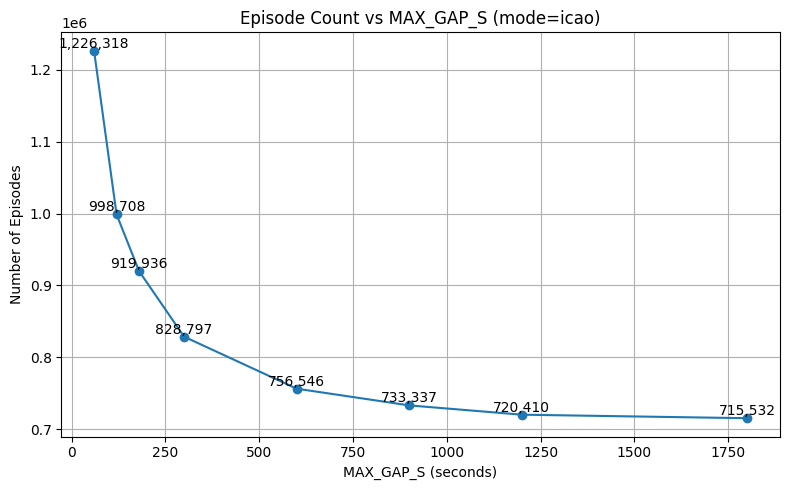

In [80]:
THRESHOLDS = np.array([60,120,180,300,600,900,1200,1800], dtype=np.int32)
MODE = "icao"
TS_COL = "point_timestamp"

required = [TS_COL, MODE]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Eksik kolon(lar): {missing}. df.columns={list(df.columns)}")

df = df.copy()
df[TS_COL] = pd.to_datetime(df[TS_COL], utc=True, errors="coerce")
df = df.dropna(subset=[MODE, TS_COL]).copy()

df = df.sort_values([MODE, TS_COL], kind="mergesort").reset_index(drop=True)

dt = df.groupby(MODE, sort=False)[TS_COL].diff().dt.total_seconds()

dt = dt.astype("float32")

base_episodes = int(df[MODE].nunique())

# =========================
# COUNT EPISODES FOR EACH THRESHOLD
# =========================
episode_counts = []
for th in THRESHOLDS:
    cuts = (dt > th)  # grup içinde gap varsa yeni episode
    n_episodes = base_episodes + int(cuts.sum())
    episode_counts.append(n_episodes)

episode_counts = np.array(episode_counts, dtype=np.int64)

# =========================
# RESULT TABLE
# =========================
res = pd.DataFrame({
    "MAX_GAP_S": THRESHOLDS,
    "n_episodes": episode_counts
})

print(res)

# =========================
# PLOT
# =========================
plt.figure(figsize=(8, 5))
plt.plot(THRESHOLDS, episode_counts, marker="o")
plt.xlabel("MAX_GAP_S (seconds)")
plt.ylabel("Number of Episodes")
plt.title(f"Episode Count vs MAX_GAP_S (mode={MODE})")
plt.grid(True)

for x, y in zip(THRESHOLDS, episode_counts):
    plt.text(int(x), int(y), f"{int(y):,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [81]:
MAX_GAP_S = 600

df = df.copy()
df["point_timestamp"] = pd.to_datetime(df["point_timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["icao", "point_timestamp"]).copy()

df = df.sort_values(["icao", "point_timestamp"]).reset_index(drop=True)

df["dt_s"] = df.groupby("icao")["point_timestamp"].diff().dt.total_seconds()

df["episode_start"] = (
    (df["dt_s"] > MAX_GAP_S) |
    df["icao"].ne(df["icao"].shift(1))
)


df["episode_id"] = df.groupby("icao")["episode_start"].cumsum().astype("int32")
df["flight_id"] = df["icao"].astype(str) + "_" + df["episode_id"].astype(str)

In [48]:
flight_stats = df.groupby("flight_id").agg(
    n_points=("point_timestamp","size"),
    t_start=("point_timestamp","min"),
    t_end=("point_timestamp","max"),
)
flight_stats["dur_s"] = (flight_stats["t_end"] - flight_stats["t_start"]).dt.total_seconds()

print(flight_stats["n_points"].describe())
print(30*"*")
print(flight_stats["dur_s"].describe())

count    756546.000000
mean         40.501224
std          36.990951
min           1.000000
25%          13.000000
50%          31.000000
75%          58.000000
max        7678.000000
Name: n_points, dtype: float64
******************************
count    756546.000000
mean        425.702408
std         360.554520
min           0.000000
25%         138.000000
50%         328.000000
75%         673.000000
max       22683.000000
Name: dur_s, dtype: float64


## Flight Filtering

## ENU Coordinate Transformation

In [616]:
import pymap3d as pm

In [617]:
LAT = 41.275278
LON = 28.751944
H0_M = 99.0

def add_enu_pymap3d(df, lat0=LAT, lon0=LON, h0_m=H0_M,
                    lat_col="latitude", lon_col="longitude", alt_ft_col="altitude_baro"):

    lat = df[lat_col].to_numpy(dtype=np.float64)
    lon = df[lon_col].to_numpy(dtype=np.float64)


    h_m = (df[alt_ft_col].to_numpy(dtype=np.float64) * 0.3048)

    # ENU (meters)
    e, n, u = pm.geodetic2enu(lat, lon, h_m, lat0, lon0, h0_m, deg=True)

    df = df.copy()
    df["e_m"] = e.astype(np.float32)
    df["n_m"] = n.astype(np.float32)
    df["u_m"] = u.astype(np.float32)
    return df


df = add_enu_pymap3d(df)

## 1 sec data resampling 